# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 

# Exercise 4.A Introduction to Linear Regression

## Lab 1
### Running a sample script

In [3]:
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)


In [4]:
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [8]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [9]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [84.6, 55.9]


In [10]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


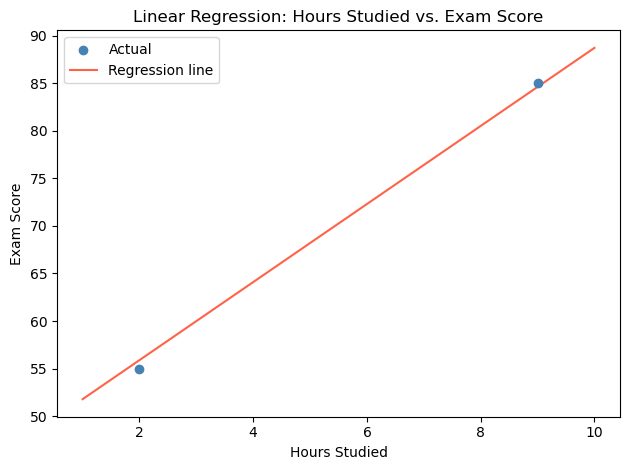

In [24]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color = 'steelblue', label = 'Actual', zorder = 3)
# Line: model predictions across the full range of X
x_range = np.linspace(
    X[['hours_studied']].min(),
    X[['hours_studied']].max(),
    100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

With this chart I can see that the regression line is not quite accurate with the actual points. The first actual point is right below the regression line and the second actual point is slightly above. Viewing without the grid line makes it difficult to visually see how off it the regression line is. 

## Lab 2
### Building your own model

In [31]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
    5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
    12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
    23800]
}
df_ads = pd.DataFrame(ad_data)

In [26]:
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [27]:
x2 = df_ads[['monthly_ad_spend']]
y2 = df_ads[['monthly_revenue']]
print(x2)
print(y2)

    monthly_ad_spend
0                500
1               1000
2               1500
3               2000
4               2500
5               3000
6               3500
7               4000
8               4500
9               5000
10              5500
11              6000
12              6500
13              7000
14              7500
15              8000
16              8500
17              9000
18              9500
19             10000
    monthly_revenue
0              4200
1              5100
2              6800
3              7400
4              8900
5              9200
6             10500
7             11800
8             12400
9             13100
10            14200
11            15600
12            15900
13            17200
14            18100
15            19400
16            20200
17            21500
18            22100
19            23800


In [29]:
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=42
)

In [30]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


In [34]:
print(f'Slope: {model2.coef_[0]:.2f}\n'
      f'Intercept: {model2.intercept_:.2f}')

Slope: 4.10
Intercept: 47.68


For each additional ad, the predicted revenue increases by 4.10 

### Making predictions and evaluating the model

In [38]:

y_pred = model2.predict(X_test)

comparison = pd.DataFrame({
    "Actual Revenue": y_test,
    "Predicted Revenue": y_pred
}).round(2)

print(comparison)


   Actual Revenue  Predicted Revenue
8              85              84.61
1              55              55.89


In [39]:
r_squared = model2.score(X_test, y_test) 
print(f'R² score: {r_squared:.2f}') 

R² score: 1.00


### Visualizing the results

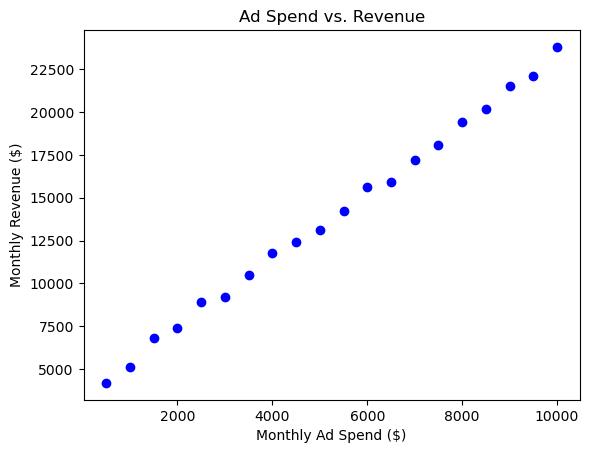

In [56]:
plt.scatter(x2, y2, c = 'blue')
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.show()

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


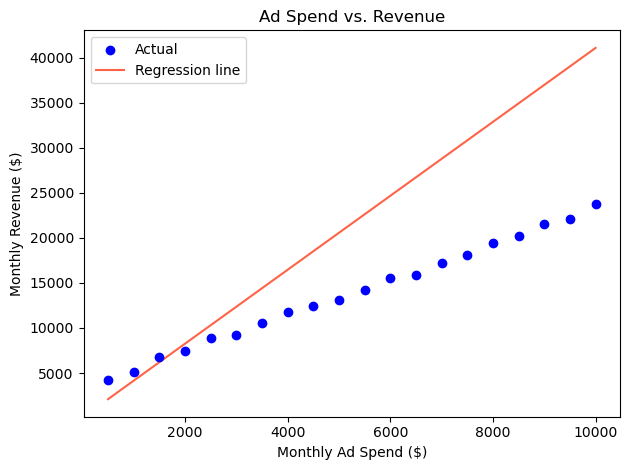

In [57]:
plt.scatter(x2, y2, c = 'blue', label = 'Actual', zorder = 3)
x_range = np.linspace(
    x2.min(),
    x2.max(),
    100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color ='tomato', label = 'Regression line')
plt.title('Ad Spend vs. Revenue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.legend()
plt.tight_layout()
plt.show()

After reviewing the graph, I was able to deduce that the regression line is no where near the actual points. I see now that using a visual representation would better be able to convey the message that the data is representing. I do see that the actual points have an